In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import networkx as nx
import csv
import json
import geopandas as gpd
import numpy as np

with open(f"Graph_mean.json", "r") as f:
    data = json.load(f)
G = nx.node_link_graph(data)

In [2]:
H = G.copy()
for nd in list(H.nodes()):
    if (nd, nd) in list(H.edges()):       
        H.remove_edge(nd, nd) # removing connections from one node to itself

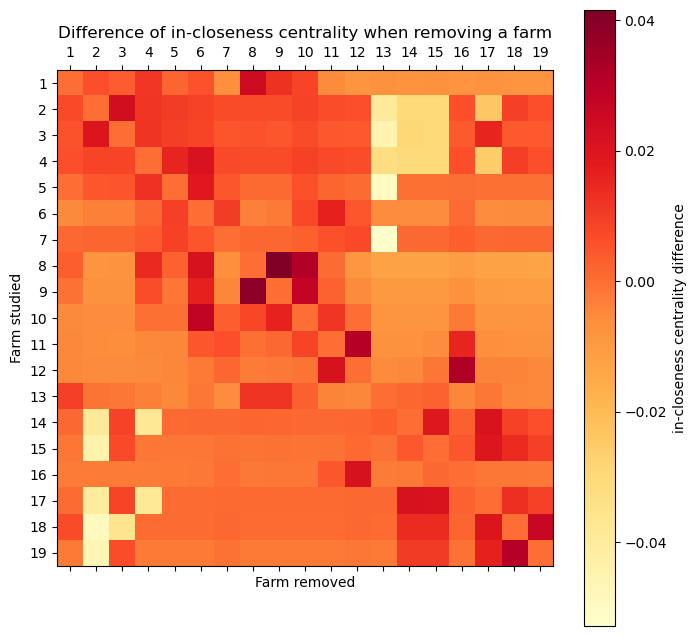

In [17]:
# difference of in-closeness centrality (removing a farm)
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = 1 - G.edges[e[0], e[1]]['prob']
    # the path is shorter when the probability is higher

in_close_init = nx.closeness_centrality(H, distance='weight')
# Calculating in-degree while removing one farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()
    H_temp.remove_node(nd1)
    in_close = nx.closeness_centrality(H_temp, distance='weight')
    for nd2 in list(H_temp.nodes()): # farm studied
        M[nd2-1, nd1-1] = in_close_init[nd2] - in_close[nd2]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='in-closeness centrality difference')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Farm removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'Difference of in-closeness centrality when removing a farm')
plt.savefig("connectivity_metrics/removing_farm_difference_in_closeness.png")
plt.show()

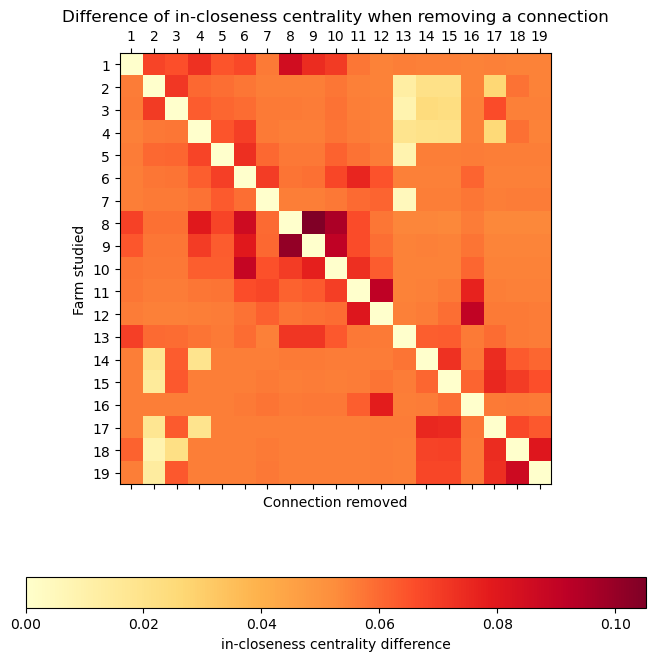

In [14]:
# difference of in-closeness centrality (removing a connection)
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = 1 - G.edges[e[0], e[1]]['prob']
    # the path is shorter when the probability is higher

in_close_init = nx.closeness_centrality(H, distance='weight')
# Calculating in-degree while removing one farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()    
    for nd2 in list(H_temp.nodes()):
        if (nd1, nd2) in list(H_temp.edges()):       
            H_temp.remove_edge(nd1, nd2) 
    in_close = nx.closeness_centrality(H_temp, distance='weight')
    for nd2 in list(H_temp.nodes()): # farm studied
        M[nd2-1, nd1-1] =  in_close_init[nd2] - in_close[nd2] 

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='in-closeness centrality difference', location='bottom')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Connection removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'Difference of in-closeness centrality when removing a connection')
plt.savefig("connectivity_metrics/removing_connection_difference_in_closeness.png")
plt.show()

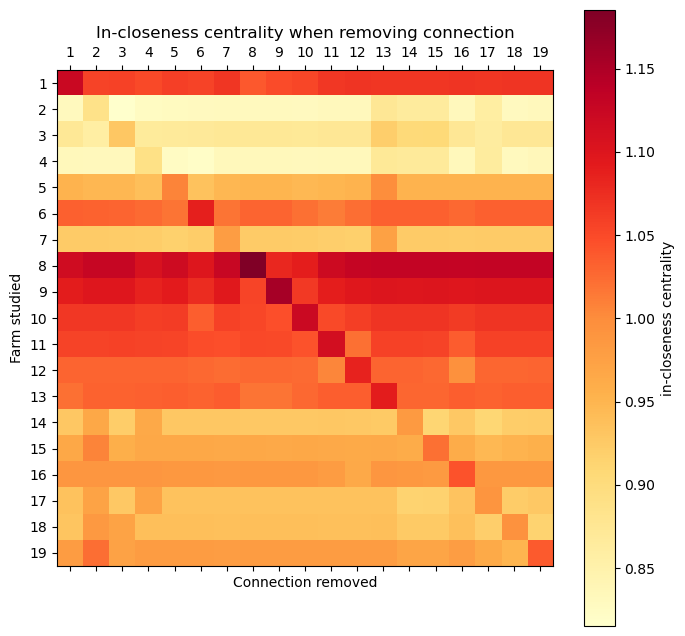

In [15]:
# in-closeness centrality (removing connection)
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = 1 - G.edges[e[0], e[1]]['prob']
    # the path is shorter when the probability is higher

# Calculating in-degree while removing one connection from a farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()    
    for nd2 in list(H_temp.nodes()):
        if (nd1, nd2) in list(H_temp.edges()):       
            H_temp.remove_edge(nd1, nd2) 
    in_close = nx.closeness_centrality(H_temp, distance='weight')
    for nd2 in list(H_temp.nodes()): # farm studied
        # M[nd2-1, nd1-1] = in_degree_init[nd2] - in_degree[nd2]
        M[nd2-1, nd1-1] =  in_close[nd2]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='in-closeness centrality')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Connection removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'In-closeness centrality when removing connection')
plt.savefig("connectivity_metrics/removing_connection_in_closeness.png")
plt.show()

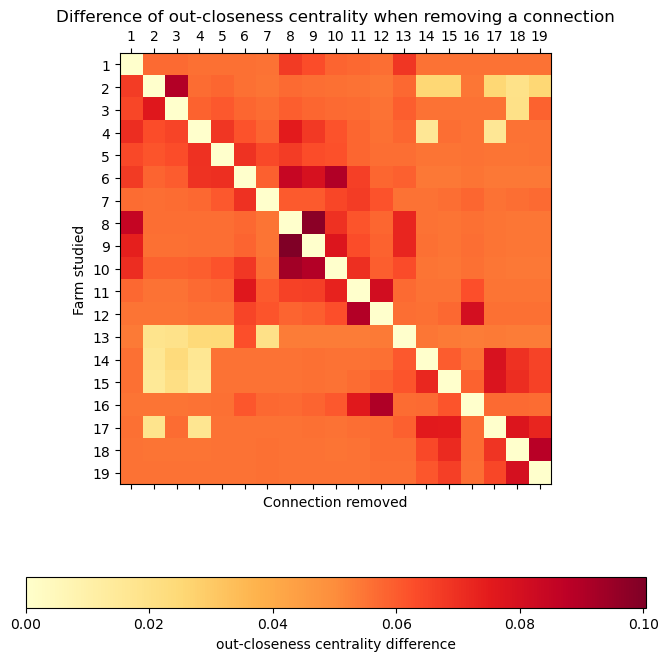

In [14]:
# difference of out-closeness centrality (removing a connection)
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = 1 - G.edges[e[0], e[1]]['prob']
    # the path is shorter when the probability is higher

out_close_init = nx.closeness_centrality(H.reverse(), distance='weight')

for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()    
    for nd2 in list(H_temp.nodes()):
        if (nd2, nd1) in list(H_temp.edges()):       
            H_temp.remove_edge(nd2, nd1) 
    out_close = nx.closeness_centrality(H_temp.reverse(), distance='weight')
    for nd2 in list(H_temp.nodes()): # farm studied
        M[nd2-1, nd1-1] =  out_close_init[nd2] - out_close[nd2] 

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')
# M_masked = np.ma.masked_where(M == 0, M) # mask exact zeros
# norm = colors.LogNorm(0.05, 0.1)

# im = ax.matshow(M, cmap='YlOrRd', norm=norm)
# im.cmap.set_bad(color='whitesmoke')


plt.colorbar(im, ax=ax, label='out-closeness centrality difference', location='bottom')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Connection removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'Difference of out-closeness centrality when removing a connection')
plt.savefig("connectivity_metrics/removing_connection_difference_out_closeness.png")
plt.show()

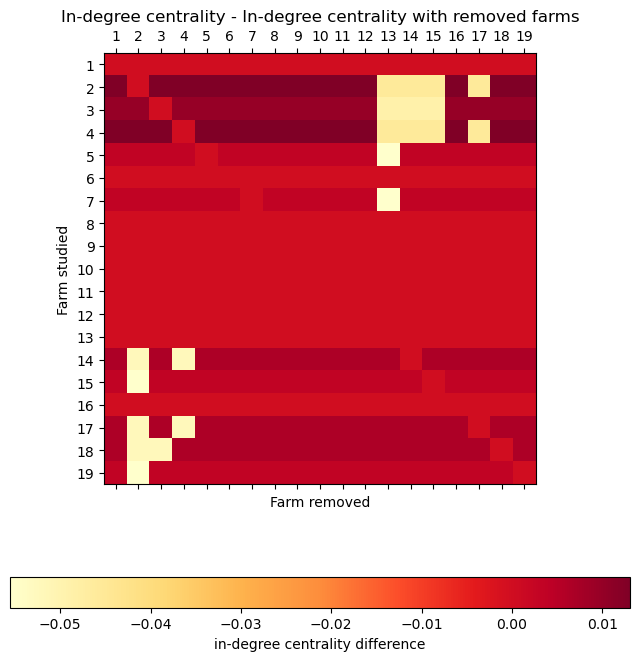

In [8]:
# in-degree centrality (removing a farm)
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

in_degree_init = nx.in_degree_centrality(H)
# Calculating in-degree while removing one farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()
    H_temp.remove_node(nd1)
    in_degree = nx.in_degree_centrality(H_temp)
    for nd2 in list(H_temp.nodes()): # farm studied
        M[nd2-1, nd1-1] = in_degree_init[nd2] - in_degree[nd2]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='in-degree centrality difference', location='bottom')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Farm removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'In-degree centrality - In-degree centrality with removed farms')
plt.savefig("connectivity_metrics/removing_farm_difference_in_degree.png")
plt.show()

In [37]:
print(in_degree_init)

{1: 1.0, 2: 0.7777777777777777, 4: 0.7777777777777777, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 13: 1.0, 14: 0.8888888888888888, 15: 0.9444444444444444, 17: 0.8888888888888888, 3: 0.8333333333333333, 5: 0.9444444444444444, 6: 1.0, 7: 0.9444444444444444, 12: 1.0, 16: 1.0, 18: 0.8888888888888888, 19: 0.9444444444444444}


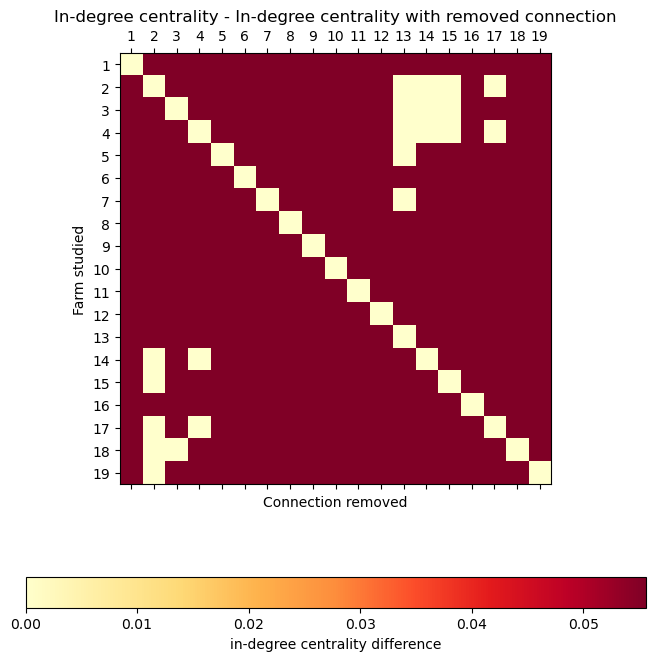

In [9]:
# in-degree centrality (removing a connection)
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

in_degree_init = nx.in_degree_centrality(H)
# Calculating in-degree while removing one farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()    
    for nd2 in list(H_temp.nodes()):
        if (nd1, nd2) in list(H_temp.edges()):       
            H_temp.remove_edge(nd1, nd2) 
    in_degree = nx.in_degree_centrality(H_temp)
    for nd2 in list(H_temp.nodes()): # farm studied
        M[nd2-1, nd1-1] = in_degree_init[nd2] - in_degree[nd2]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='in-degree centrality difference', location='bottom')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Connection removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'In-degree centrality - In-degree centrality with removed connection')
plt.savefig("connectivity_metrics/removing_connection_difference_in_degree.png")
plt.show()

In [38]:
print(in_degree_init)

{1: 1.0, 2: 0.7777777777777777, 4: 0.7777777777777777, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 13: 1.0, 14: 0.8888888888888888, 15: 0.9444444444444444, 17: 0.8888888888888888, 3: 0.8333333333333333, 5: 0.9444444444444444, 6: 1.0, 7: 0.9444444444444444, 12: 1.0, 16: 1.0, 18: 0.8888888888888888, 19: 0.9444444444444444}


In [40]:
M[1]

array([0.05555556, 0.        , 0.05555556, 0.05555556, 0.05555556,
       0.05555556, 0.05555556, 0.05555556, 0.05555556, 0.05555556,
       0.05555556, 0.05555556, 0.        , 0.        , 0.        ,
       0.05555556, 0.        , 0.05555556, 0.05555556])

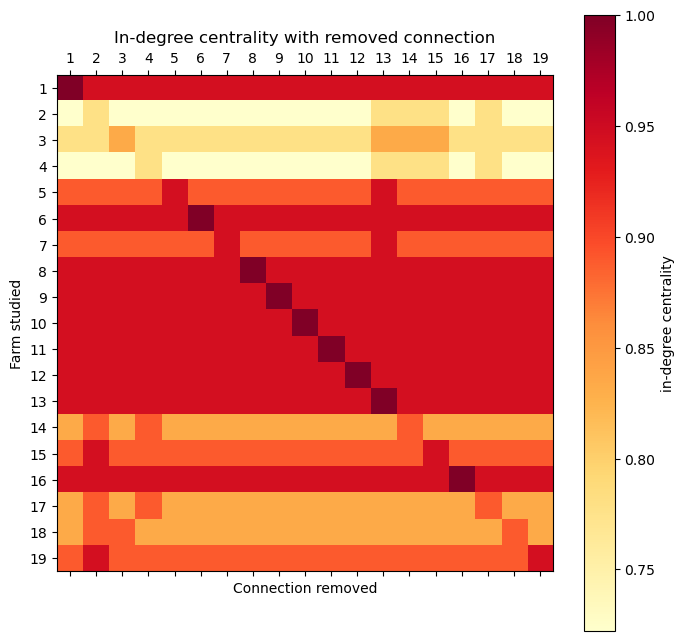

In [12]:
# in-degree centrality
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

in_degree_init = nx.in_degree_centrality(H)
# Calculating in-degree while removing one farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()    
    for nd2 in list(H_temp.nodes()):
        if (nd1, nd2) in list(H_temp.edges()):       
            H_temp.remove_edge(nd1, nd2) 
    in_degree = nx.in_degree_centrality(H_temp)
    for nd2 in list(H_temp.nodes()): # farm studied
        # M[nd2-1, nd1-1] = in_degree_init[nd2] - in_degree[nd2]
        M[nd2-1, nd1-1] =  in_degree[nd2]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='in-degree centrality')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Connection removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'In-degree centrality with removed connection')
plt.savefig("connectivity_metrics/removing_connection_in_degree.png")
plt.show()

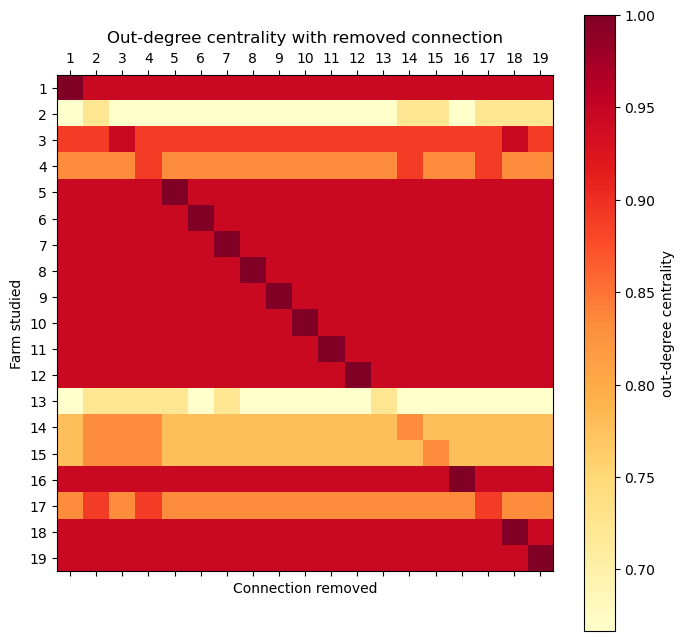

In [4]:
# out-degree centrality
farmIDs = np.arange(1, 20)
axis = np.arange(0, 19)
M = np.zeros((19,19))

out_degree_init = nx.out_degree_centrality(H)
# Calculating in-degree while removing one farm after another
for nd1 in list(H.nodes()): # farm removed
    H_temp = H.copy()    
    for nd2 in list(H_temp.nodes()):
        if (nd2, nd1) in list(H_temp.edges()):       
            H_temp.remove_edge(nd2, nd1) 
    out_degree = nx.out_degree_centrality(H_temp)
    for nd2 in list(H_temp.nodes()): # farm studied
        # M[nd2-1, nd1-1] = out_degree_init[nd2] - out_degree[nd2]
        M[nd2-1, nd1-1] =  out_degree[nd2]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(M, cmap='YlOrRd')

plt.colorbar(im, ax=ax, label='out-degree centrality')
plt.xticks(axis, farmIDs)
plt.yticks(axis, farmIDs)
ax.set_xlabel("Connection removed")
ax.set_ylabel("Farm studied")
ax.set_title(f'Out-degree centrality with removed connection')
plt.savefig("connectivity_metrics/removing_connection_out_degree.png")
plt.show()